# Taller final APO III: clasificación de calidad de frutas

Este notebook implementa una solución base para el caso de estudio del README usando tres categorías finales: **bueno**, **regular** y **malo**.

## CRISP-DM
1. Comprensión del negocio (Sección 1)
2. Comprensión de los datos (Sección 2)
3. Verificación de balance (Sección 3) + Preparación de los datos (Sección 4)
4. Vectorización y Modelado (Secciones 5, 6, 8)
5. Evaluación (Secciones 3, 7)
6. Despliegue / uso del modelo (Secciones 9, 10)

## Estructura esperada de los datos
Se espera una carpeta con subcarpetas por clase:

- `data/bueno/`
- `data/regular/`
- `data/malo/`

Cada subcarpeta debe contener imágenes `.jpg`, `.png` o `.jpeg`.

In [11]:
import subprocess, sys, importlib, pkgutil, os
required = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "Pillow", "tensorflow", "joblib"]
missing = [p for p in required if not importlib.util.find_spec(p)]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    precision_recall_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

np.random.seed(42)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"

try:
    import tensorflow as tf
    from tensorflow import keras
    tf.random.set_seed(42)
except ImportError:
    raise RuntimeError(
        "TensorFlow es obligatorio para la CNN. "
        "Asegúrate de usar Python 3.10-3.12 y ejecutar: pip install tensorflow"
    )


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Comprensión del negocio

El objetivo es automatizar la clasificación visual de frutas para apoyar una línea de empaque o un sistema de inspección básica.

Las categorías finales del proyecto son:
- bueno
- regular
- malo

Estas etiquetas pueden representar fruta visualmente apta, con defectos leves o con deterioro evidente.

In [12]:
# Ruta base del dataset. Ajusta esta variable si tus imágenes están en otro lugar.
DATA_DIR = Path("data")
CLASS_NAMES = ["bueno", "regular", "malo"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not DATA_DIR.exists():
    print(f"La carpeta {DATA_DIR.resolve()} no existe todavía.")
    print("Crea la estructura data/bueno, data/regular y data/malo, o cambia DATA_DIR.")

rows = []
if DATA_DIR.exists():
    for class_name in CLASS_NAMES:
        class_dir = DATA_DIR / class_name
        if class_dir.exists():
            for file_path in class_dir.rglob("*"):
                if file_path.suffix.lower() in IMAGE_EXTENSIONS:
                    rows.append({"filepath": str(file_path), "label": class_name})

images_df = pd.DataFrame(rows)
print(f"Imágenes encontradas: {len(images_df)}")
images_df.head()

if not images_df.empty:
    display(images_df.sample(min(5, len(images_df)), random_state=42))
    print(images_df["label"].value_counts())

Imágenes encontradas: 27944


,filepath,label
14401,data/regular/Pomegranate_Regular/Captura de pa...,regular
23009,data/malo/Lime_Bad/IMG_7223.JPG,malo
11624,data/bueno/Banana_Good/IMG20200730132027_01.jpg,bueno
22344,data/malo/Orange_Bad/vertical_flip_Screen Shot...,malo
2595,data/bueno/Pomegranate_Good/20190820_152236.jpg,bueno


label
bueno      14307
malo        9024
regular     4613
Name: count, dtype: int64


## 2. Comprensión de los datos

Se revisa la distribución de clases y algunos ejemplos visuales para verificar variabilidad, fondo, iluminación y calidad general de las imágenes.

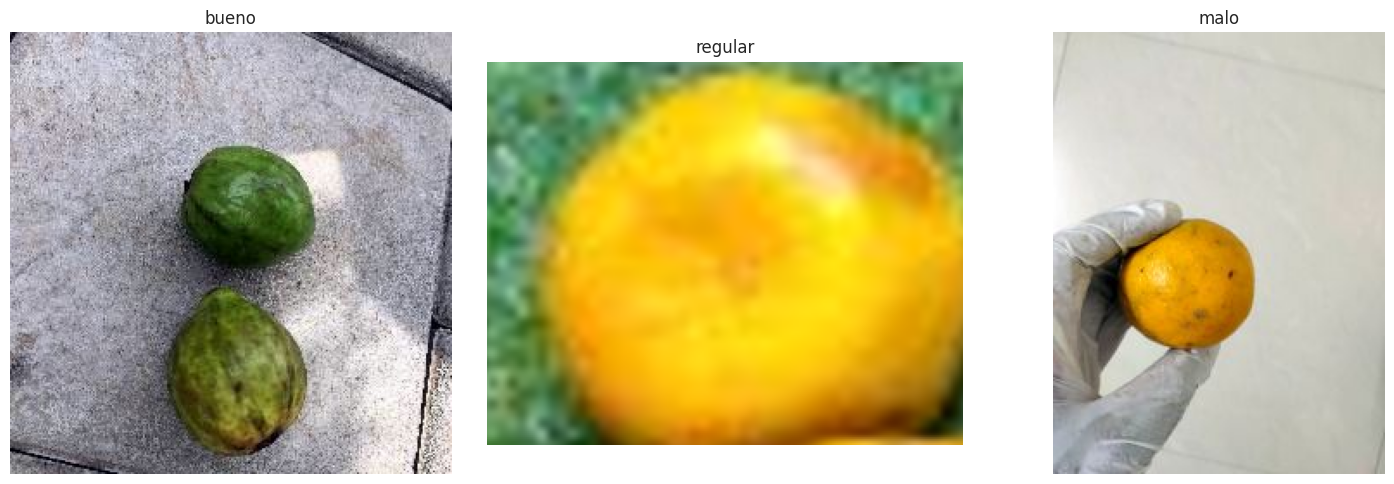

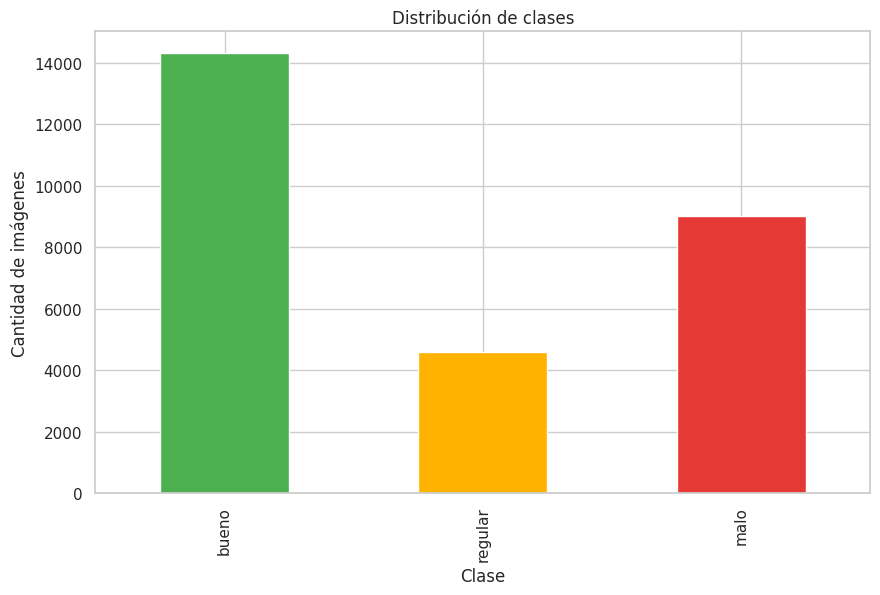

In [13]:
if not images_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, class_name in zip(axes, CLASS_NAMES):
        subset = images_df[images_df["label"] == class_name]
        if subset.empty:
            ax.axis("off")
            ax.set_title(f"Sin imágenes: {class_name}")
            continue
        sample_path = subset.sample(1, random_state=42)["filepath"].iloc[0]
        img = Image.open(sample_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(class_name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    counts = images_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    counts.plot(kind="bar", color=["#4caf50", "#ffb300", "#e53935"])
    plt.title("Distribución de clases")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad de imágenes")
    plt.show()

## 3. Verificación de balance de clases

Se verifica que las clases estén balanceadas. Si hay desbalanceo severo, se recomienda usar `class_weight` (ya configurado) o técnicas de sobremuestreo como SMOTE.

In [14]:
if not images_df.empty:
    counts = images_df["label"].value_counts()
    print("Distribución de clases:")
    for cls in CLASS_NAMES:
        count = counts.get(cls, 0)
        pct = count / len(images_df) * 100
        print(f"  {cls}: {count} ({pct:.1f}%)")
    min_count = counts.min()
    max_count = counts.max()
    ratio = max_count / min_count if min_count > 0 else float("inf")
    print(f"\nRelación mayor/menor: {ratio:.1f}x")
    if ratio > 2.0:
        print("⚠️  Desbalanceo significativo. Considera aplicar SMOTE o aumentar datos de clases minoritarias.")
    else:
        print("✅ Clases razonablemente balanceadas.")

Distribución de clases:
  bueno: 14307 (51.2%)
  regular: 4613 (16.5%)
  malo: 9024 (32.3%)

Relación mayor/menor: 3.1x
⚠️  Desbalanceo significativo. Considera aplicar SMOTE o aumentar datos de clases minoritarias.


## 4. Preparación de los datos

Se dividen los datos en entrenamiento, validación y prueba, manteniendo la proporción de clases con `stratify`. Luego se aplica balanceo por subcarpeta únicamente sobre el conjunto de entrenamiento para evitar contaminar validación y prueba.

In [15]:
if images_df.empty:
    raise ValueError("No se encontraron imágenes. Agrega datos a data/bueno, data/regular y data/malo.")

X_paths = images_df["filepath"].to_numpy()
y_labels = images_df["label"].to_numpy()

X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    X_paths,
    y_labels,
    test_size=0.30,
    random_state=42,
    stratify=y_labels,
)

X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
)

print("Tamaño train:", len(X_train_paths))
print("Tamaño val:", len(X_val_paths))
print("Tamaño test:", len(X_test_paths))
print("Distribución train:\n", pd.Series(y_train).value_counts())

# Balanceo por subcarpeta (solo entrenamiento)
train_df = pd.DataFrame({"filepath": X_train_paths, "label": y_train})
parent_dirs = set(Path(p).parent.name for p in train_df["filepath"])
if parent_dirs:
    for cls in CLASS_NAMES:
        cls_mask = train_df["label"] == cls
        sub_names = train_df.loc[cls_mask, "filepath"].apply(lambda p: Path(p).parent.name)
        sub_counts = sub_names.value_counts()
        if len(sub_counts) <= 1:
            continue
        median_count = int(sub_counts.median())
        max_allowed = max(int(median_count * 1.5), 1)
        keep = []
        for sub_name in sub_counts.index:
            sub_mask = cls_mask & (train_df["filepath"].apply(lambda p: Path(p).parent.name) == sub_name)
            subset = train_df[sub_mask]
            if len(subset) > max_allowed:
                subset = subset.sample(n=max_allowed, random_state=42)
            keep.append(subset)
        train_df = pd.concat([train_df[~cls_mask]] + keep)
X_train_paths = train_df["filepath"].to_numpy()
y_train = train_df["label"].to_numpy()
print(f"\nTrain después de balancear: {len(X_train_paths)} imágenes")
for cls in CLASS_NAMES:
    print(f"  {cls}: {sum(y_train == cls)}")

Tamaño train: 19560
Tamaño val: 4192
Tamaño test: 4192
Distribución train:
 bueno      10014
malo        6317
regular     3229
Name: count, dtype: int64

Train después de balancear: 15491 imágenes
  bueno: 6112
  regular: 3229
  malo: 6150


## 5. Vectorización de imágenes para modelos tradicionales

Para los modelos clásicos se extraen características simples a partir de la imagen: píxeles reescalados y histogramas de color.

In [16]:
IMG_SIZE = (64, 64)
HIST_BINS = 32


def resize_with_padding(image, target_size, bg_color=(255, 255, 255)):
    original_width, original_height = image.size
    aspect_ratio = original_width / original_height
    target_width, target_height = target_size
    if aspect_ratio > 1:
        new_width = target_width
        new_height = int(target_width / aspect_ratio)
    else:
        new_height = target_height
        new_width = int(target_height * aspect_ratio)
    image_resized = image.resize((new_width, new_height), Image.Resampling.LANCZOS)
    final_image = Image.new("RGB", target_size, bg_color)
    offset_x = (target_width - new_width) // 2
    offset_y = (target_height - new_height) // 2
    final_image.paste(image_resized, (offset_x, offset_y))
    return final_image


def load_image_array(path, size=IMG_SIZE):
    image = Image.open(path).convert("RGB")
    image = resize_with_padding(image, size)
    return np.asarray(image, dtype=np.float32) / 255.0


def extract_features(path):
    arr = load_image_array(path)
    hist_features = []
    for channel in range(3):
        channel_values = arr[:, :, channel].ravel()
        hist, _ = np.histogram(channel_values, bins=HIST_BINS, range=(0.0, 1.0))
        hist_features.append(hist)
    mean = arr.mean(axis=(0, 1))
    std = arr.std(axis=(0, 1))
    return np.concatenate([np.concatenate(hist_features), mean, std])


X_train_feat = np.vstack([extract_features(p) for p in X_train_paths])
X_val_feat = np.vstack([extract_features(p) for p in X_val_paths])
X_test_feat = np.vstack([extract_features(p) for p in X_test_paths])

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

print("Forma de X_train_feat:", X_train_feat.shape)
print("Clases:", list(label_encoder.classes_))

Forma de X_train_feat: (15491, 102)
Clases: ['bueno', 'malo', 'regular']


## 6. Modelado con aprendizaje tradicional

Se entrenan y comparan dos clasificadores clásicos sobre las características extraídas de las imágenes: **Logistic Regression** y **Random Forest**.

In [17]:
models = {
    "logistic_regression": GridSearchCV(
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)),
            ]
        ),
        param_grid={
            "clf__C": [0.1, 1.0, 10.0],
        },
        scoring="f1_macro",
        cv=5,
        n_jobs=-1,
        verbose=1,
    ),
    "random_forest": GridSearchCV(
        RandomForestClassifier(class_weight="balanced", random_state=42),
        param_grid={
            "n_estimators": [100, 200, 300],
            "min_samples_split": [2, 5],
            "max_features": ["sqrt", "log2"],
            "max_depth": [None, 10, 20],
        },
        scoring="f1_macro",
        cv=5,
        n_jobs=-1,
        verbose=1,
    ),
}

best_model_name = None
best_model = None
best_val_score = -np.inf
results_val = []

for name, search in models.items():
    print(f"Entrenando {name}...")
    search.fit(X_train_feat, y_train_enc)
    val_pred = search.predict(X_val_feat)
    val_f1 = f1_score(y_val_enc, val_pred, average="macro")
    results_val.append({"modelo": name, "val_f1_macro": val_f1})
    print(f"{name} -> val_f1_macro = {val_f1:.4f}")
    if val_f1 > best_val_score:
        best_val_score = val_f1
        best_model_name = name
        best_model = search.best_estimator_

results_val_df = pd.DataFrame(results_val).sort_values("val_f1_macro", ascending=False)
display(results_val_df)
print("Mejor modelo:", best_model_name)
print("Mejor score de validación:", best_val_score)

Entrenando logistic_regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
logistic_regression -> val_f1_macro = 0.7363
Entrenando random_forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
random_forest -> val_f1_macro = 0.9666


,modelo,val_f1_macro
1,random_forest,0.966562
0,logistic_regression,0.736295


Mejor modelo: random_forest
Mejor score de validación: 0.9665624985203388


## 7. Evaluación del mejor modelo tradicional

Se reportan métricas sobre el conjunto de prueba y una matriz de confusión para identificar errores frecuentes.

MÉTRICAS GLOBALES
Accuracy:       0.9635
Precision macro:0.9579
Recall macro:   0.9653
F1 macro:       0.9615
F1 micro:       0.9635

REPORTE POR CLASE
              precision    recall  f1-score   support

       bueno       0.98      0.96      0.97      2147
        malo       0.94      0.96      0.95      1353
     regular       0.95      0.98      0.96       692

    accuracy                           0.96      4192
   macro avg       0.96      0.97      0.96      4192
weighted avg       0.96      0.96      0.96      4192

MATRIZ DE CONFUSIÓN


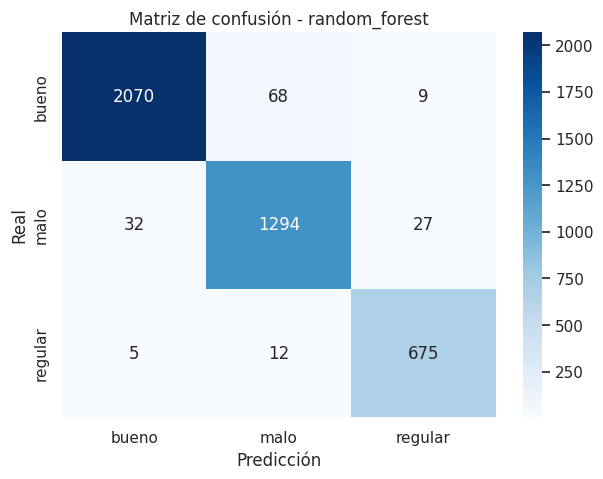

GRÁFICA: PRECISION / RECALL / F1 POR CLASE


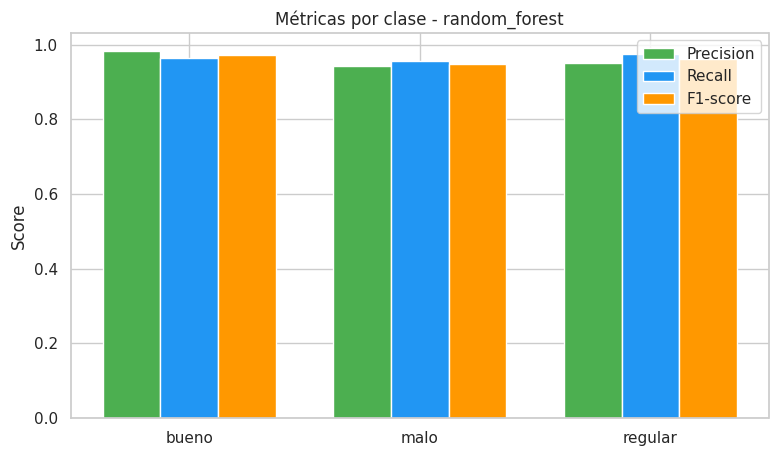

CURVAS ROC (One-vs-Rest)


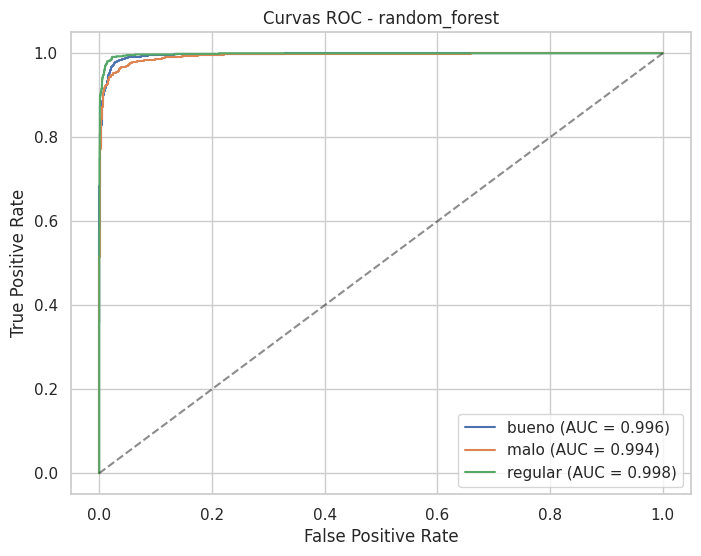

CURVAS PRECISION-RECALL


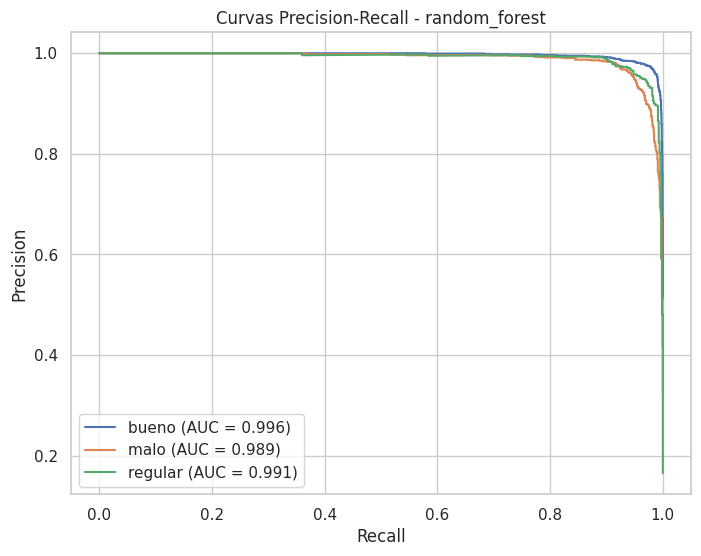

COMPARACIÓN DE MODELOS (validación)


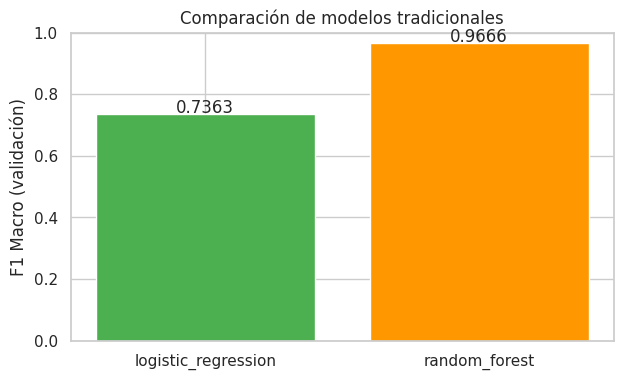

IMPORTANCIA DE CARACTERÍSTICAS


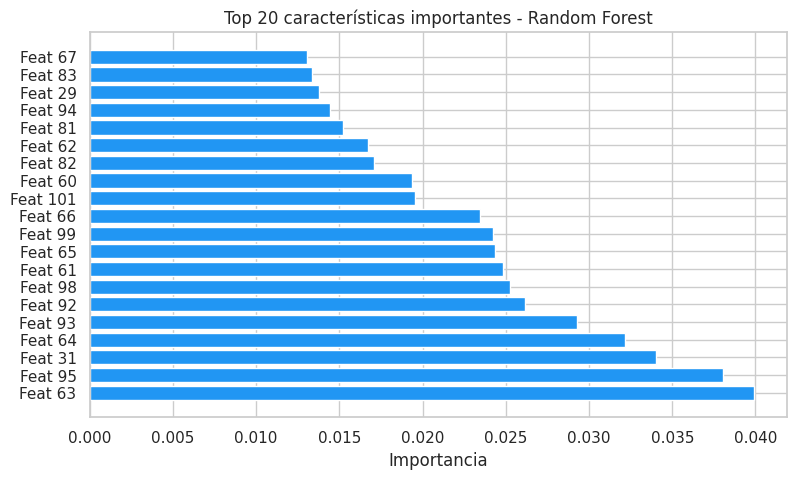

ANÁLISIS DE ERRORES
Total de errores: 153 / 4192 (3.65%)


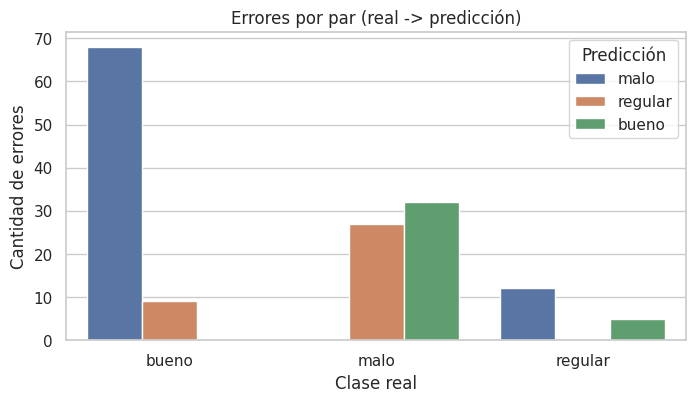


Ejemplos mal clasificados (primeros 10):


,filepath,y_true,y_pred
7,data/bueno/Pomegranate_Good/IMG20200728181719.jpg,bueno,malo
57,data/bueno/Guava_Good/IMG20200728184209.jpg,bueno,malo
66,data/bueno/Guava_Good/IMG20200729172825.jpg,bueno,malo
111,data/bueno/Apple_Good/20190812_182430.jpg,bueno,malo
163,data/regular/Guava_Regular/guava_029_007.jpg,regular,malo
164,data/malo/Banana_Bad/banana_024_008.jpg,malo,regular
173,data/bueno/Pomegranate_Good/IMG20200728182218.jpg,bueno,malo
187,data/regular/Banana_Regular/banana_011_014.jpg,regular,malo
201,data/malo/Banana_Bad/banana_030_006.jpg,malo,regular
214,data/bueno/Apple_Good/20190809_160557.jpg,bueno,malo


In [18]:
test_pred = best_model.predict(X_test_feat)
classes = label_encoder.classes_
n_classes = len(classes)

print("=" * 50)
print("MÉTRICAS GLOBALES")
print("=" * 50)
acc = accuracy_score(y_test_enc, test_pred)
prec_macro = precision_score(y_test_enc, test_pred, average="macro", zero_division=0)
rec_macro = recall_score(y_test_enc, test_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_test_enc, test_pred, average="macro")
f1_micro = f1_score(y_test_enc, test_pred, average="micro")
print(f"Accuracy:       {acc:.4f}")
print(f"Precision macro:{prec_macro:.4f}")
print(f"Recall macro:   {rec_macro:.4f}")
print(f"F1 macro:       {f1_macro:.4f}")
print(f"F1 micro:       {f1_micro:.4f}")

print("\n" + "=" * 50)
print("REPORTE POR CLASE")
print("=" * 50)
report = classification_report(y_test_enc, test_pred, target_names=classes, zero_division=0)
print(report)

print("=" * 50)
print("MATRIZ DE CONFUSIÓN")
print("=" * 50)
cm = confusion_matrix(y_test_enc, test_pred)
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

print("=" * 50)
print("GRÁFICA: PRECISION / RECALL / F1 POR CLASE")
print("=" * 50)
per_class = precision_score(y_test_enc, test_pred, average=None, zero_division=0)
per_recall = recall_score(y_test_enc, test_pred, average=None, zero_division=0)
per_f1 = f1_score(y_test_enc, test_pred, average=None)
x = np.arange(n_classes)
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, per_class, width, label="Precision", color="#4CAF50")
ax.bar(x, per_recall, width, label="Recall", color="#2196F3")
ax.bar(x + width, per_f1, width, label="F1-score", color="#FF9800")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("Score")
ax.set_title(f"Métricas por clase - {best_model_name}")
ax.legend()
plt.show()

print("=" * 50)
print("CURVAS ROC (One-vs-Rest)")
print("=" * 50)
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test_feat)
    y_test_bin = pd.get_dummies(y_test_enc).values
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Curvas ROC - {best_model_name}")
    ax.legend(loc="lower right")
    plt.show()
else:
    print("(El modelo no soporta predict_proba, se omiten curvas ROC)")

print("=" * 50)
print("CURVAS PRECISION-RECALL")
print("=" * 50)
if hasattr(best_model, "predict_proba"):
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(n_classes):
        precision_vals, recall_vals, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
        pr_auc = auc(recall_vals, precision_vals)
        ax.plot(recall_vals, precision_vals, label=f"{classes[i]} (AUC = {pr_auc:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Curvas Precision-Recall - {best_model_name}")
    ax.legend(loc="lower left")
    plt.show()

print("=" * 50)
print("COMPARACIÓN DE MODELOS (validación)")
print("=" * 50)
if len(results_val) > 0:
    val_df = pd.DataFrame(results_val)
    plt.figure(figsize=(7, 4))
    colors = ["#4CAF50", "#FF9800", "#2196F3"][:len(val_df)]
    plt.bar(val_df["modelo"], val_df["val_f1_macro"], color=colors)
    plt.ylabel("F1 Macro (validación)")
    plt.title("Comparación de modelos tradicionales")
    for i, row in val_df.iterrows():
        plt.text(i, row["val_f1_macro"] + 0.005, f"{row['val_f1_macro']:.4f}", ha="center")
    plt.ylim(0, 1)
    plt.show()

print("=" * 50)
print("IMPORTANCIA DE CARACTERÍSTICAS")
print("=" * 50)
if best_model_name == "random_forest":
    rf_model = best_model.named_steps["classifier"] if hasattr(best_model, "named_steps") else best_model
    if hasattr(rf_model, "feature_importances_"):
        importances = rf_model.feature_importances_
        top_n = min(20, len(importances))
        top_idx = np.argsort(importances)[-top_n:]
        plt.figure(figsize=(9, 5))
        plt.barh(range(top_n), importances[top_idx], color="#2196F3")
        plt.yticks(range(top_n), [f"Feat {i}" for i in top_idx])
        plt.xlabel("Importancia")
        plt.title(f"Top {top_n} características importantes - Random Forest")
        plt.gca().invert_yaxis()
        plt.show()

print("=" * 50)
print("ANÁLISIS DE ERRORES")
print("=" * 50)
errors_df = pd.DataFrame({
    "filepath": X_test_paths,
    "y_true": label_encoder.inverse_transform(y_test_enc),
    "y_pred": label_encoder.inverse_transform(test_pred),
})
errors_df = errors_df[errors_df["y_true"] != errors_df["y_pred"]]
print(f"Total de errores: {len(errors_df)} / {len(X_test_paths)} ({100*len(errors_df)/len(X_test_paths):.2f}%)")
if len(errors_df) > 0:
    error_pairs = errors_df.groupby(["y_true", "y_pred"]).size().reset_index(name="count")
    plt.figure(figsize=(8, 4))
    sns.barplot(data=error_pairs, x="y_true", y="count", hue="y_pred")
    plt.title("Errores por par (real -> predicción)")
    plt.xlabel("Clase real")
    plt.ylabel("Cantidad de errores")
    plt.legend(title="Predicción")
    plt.show()
print("\nEjemplos mal clasificados (primeros 10):")
display(errors_df.head(10))

## 8. Modelado con deep learning

Si TensorFlow está disponible, se entrena una CNN simple sobre las imágenes redimensionadas y normalizadas.

Epoch 1/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.7394 - loss: 0.6041 - val_accuracy: 0.8638 - val_loss: 0.3443
Epoch 2/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 361s 746ms/step - accuracy: 0.8721 - loss: 0.3461 - val_accuracy: 0.9027 - val_loss: 0.2880
Epoch 3/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 56s 116ms/step - accuracy: 0.9038 - loss: 0.2678 - val_accuracy: 0.9060 - val_loss: 0.2510
Epoch 4/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 50s 104ms/step - accuracy: 0.9187 - loss: 0.2242 - val_accuracy: 0.9416 - val_loss: 0.1667
Epoch 5/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 52s 107ms/step - accuracy: 0.9318 - loss: 0.1853 - val_accuracy: 0.9492 - val_loss: 0.1409
Epoch 6/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 54s 112ms/step - accuracy: 0.9416 - loss: 0.1652 - val_accuracy: 0.9540 - val_loss: 0.1354
Epoch 7/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 54s 111ms/step - accuracy: 0.9476 - loss: 0.1515 - val_accuracy: 0.9664 - val_loss: 0.1073
Epoch 8/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 54s 110ms/step - accuracy: 0.9538 - loss: 0

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,050,763 (7.82 MB)

 Trainable params: 683,587 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,367,176 (5.22 MB)

CURVAS DE ENTRENAMIENTO


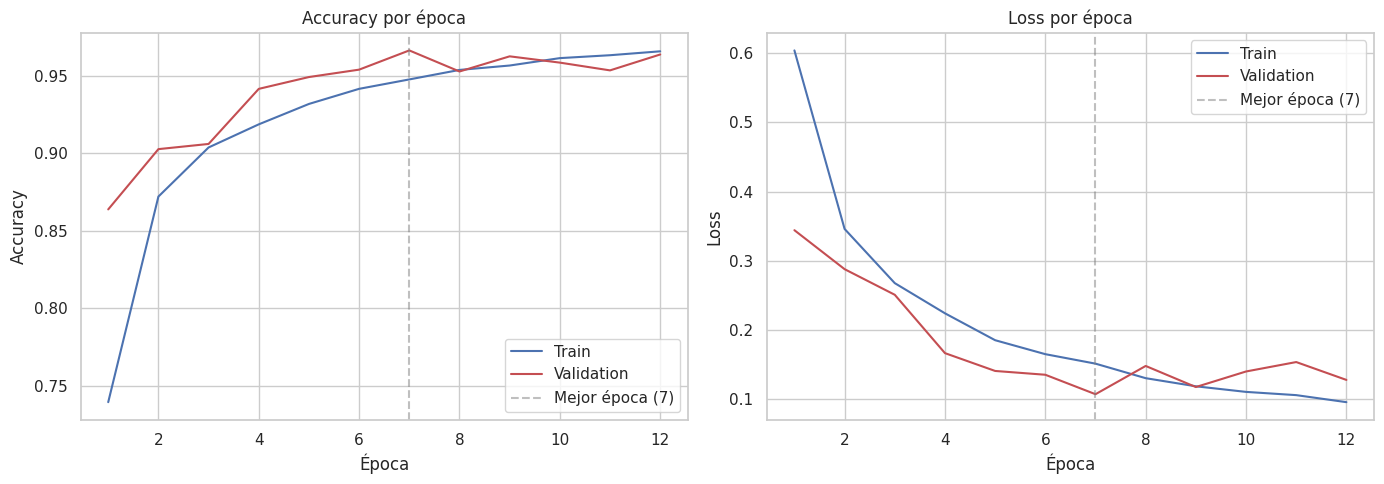

PREDICCIONES EN TEST
Accuracy:       0.9635
Precision macro:0.9613
Recall macro:   0.9601
F1 macro:       0.9605

REPORTE POR CLASE - CNN
              precision    recall  f1-score   support

       bueno       0.98      0.96      0.97      2147
        malo       0.93      0.97      0.95      1353
     regular       0.97      0.94      0.96       692

    accuracy                           0.96      4192
   macro avg       0.96      0.96      0.96      4192
weighted avg       0.96      0.96      0.96      4192

MATRIZ DE CONFUSIÓN - CNN


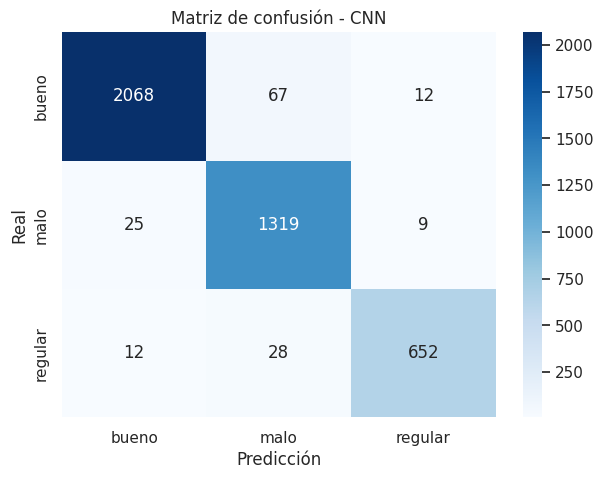

GRÁFICA: PRECISION / RECALL / F1 POR CLASE - CNN


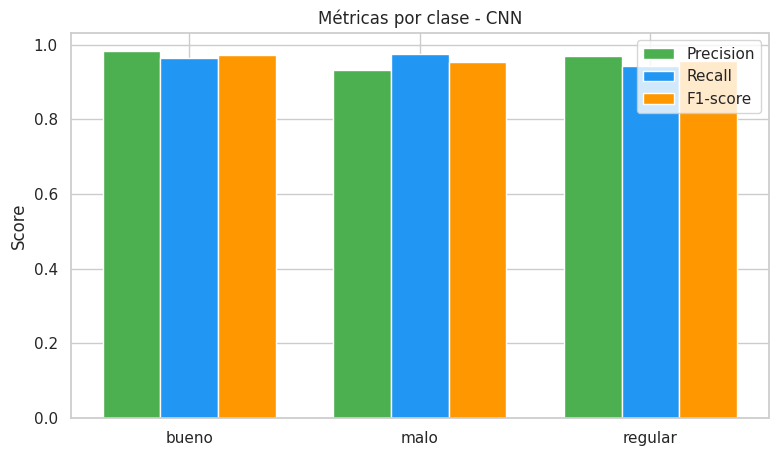

CURVAS ROC - CNN (One-vs-Rest)


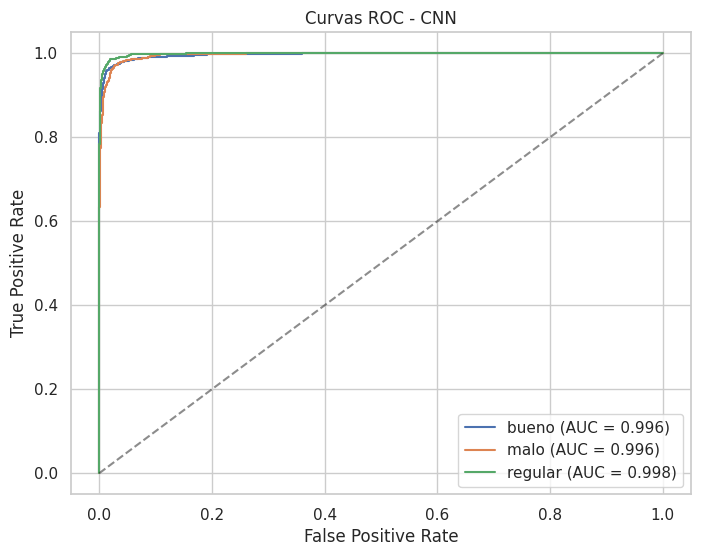

CURVAS PRECISION-RECALL - CNN


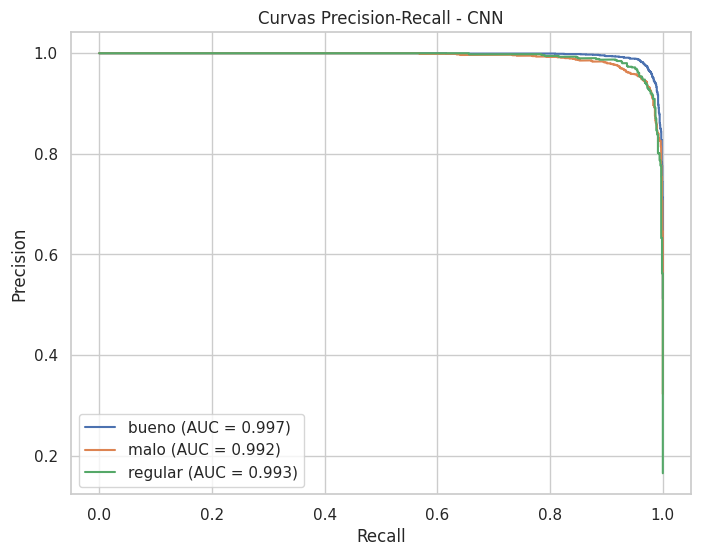

EJEMPLOS MAL CLASIFICADOS - CNN
Total de errores: 153 / 4192 (3.65%)


,filepath,y_true,y_pred
11,data/bueno/Apple_Good/IMG20200728174035.jpg,bueno,malo
13,data/regular/Lime_Regular/20260524_180628_aug_...,regular,malo
35,data/malo/Lime_Bad/20260602_070551_aug_006.jpg,malo,bueno
46,data/malo/Apple_Bad/IMG-20260603-WA0204.jpg,malo,bueno
66,data/bueno/Guava_Good/IMG20200729172825.jpg,bueno,malo
111,data/bueno/Apple_Good/20190812_182430.jpg,bueno,malo
115,data/malo/Banana_Bad/IMG_20190910_175353.jpg,malo,bueno
158,data/regular/Banana_Regular/banana_018_007.jpg,regular,malo
163,data/regular/Guava_Regular/guava_029_007.jpg,regular,malo
201,data/malo/Banana_Bad/banana_030_006.jpg,malo,regular


MUESTRAS DE DATA AUGMENTATION


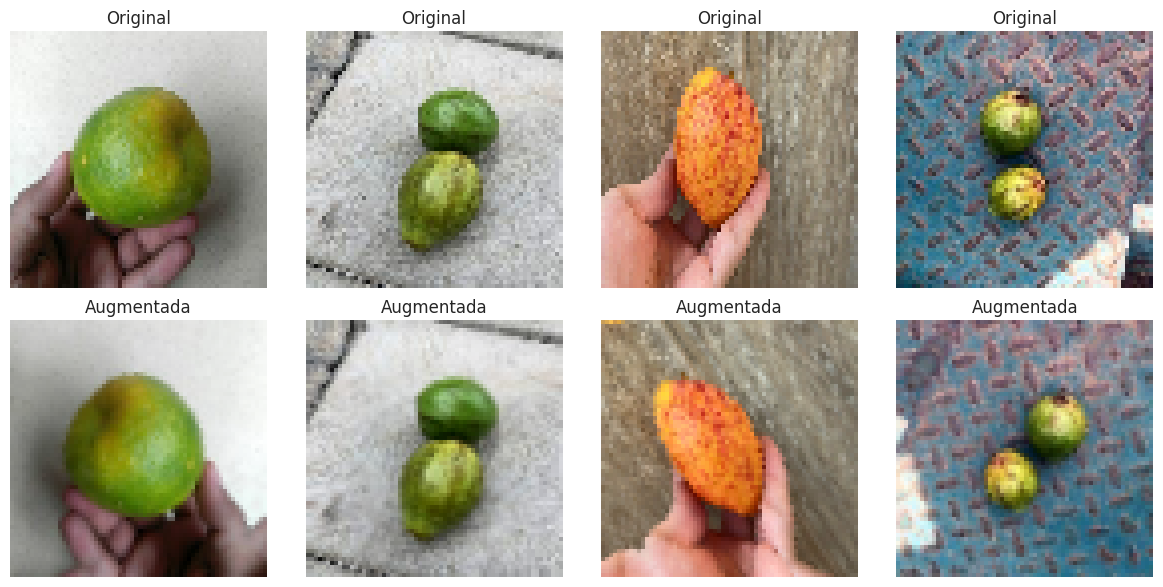

TABLA COMPARATIVA: TRADICIONALES vs CNN


,Modelo,Accuracy,Precision,Recall,F1
0,random_forest,0.9635,0.9579,0.9653,0.9615
1,CNN,0.9635,0.9613,0.9601,0.9605


In [19]:
cnn_history = None
cnn_model = None
cnn_test_metrics = None
cnn_classes = label_encoder.classes_
cnn_n_classes = len(cnn_classes)

if tf is None:
    print("TensorFlow no está disponible, por lo que se omite el entrenamiento CNN.")
else:
    image_size = IMG_SIZE
    batch_size = 32

    def decode_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, image_size)
        image = tf.cast(image, tf.float32) / 255.0
        label = tf.one_hot(label, depth=cnn_n_classes)
        return image, label

    train_ds = tf.data.Dataset.from_tensor_slices((X_train_paths, y_train_enc))
    train_ds = train_ds.shuffle(buffer_size=len(X_train_paths), seed=42).map(decode_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val_paths, y_val_enc))
    val_ds = val_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    test_ds = tf.data.Dataset.from_tensor_slices((X_test_paths, y_test_enc))
    test_ds = test_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    data_augmentation = keras.Sequential([
        keras.layers.RandomFlip("horizontal", seed=42),
        keras.layers.RandomRotation(0.1, seed=42),
        keras.layers.RandomContrast(0.1, seed=42),
    ])

    cnn_model = keras.Sequential([
        keras.layers.Input(shape=(image_size[0], image_size[1], 3)),
        data_augmentation,
        keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(64, 3, activation="relu"),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(128, 3, activation="relu"),
        keras.layers.MaxPooling2D(),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(cnn_n_classes, activation="softmax"),
    ])

    cnn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ]

    cnn_history = cnn_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=callbacks,
        verbose=1,
    )

    cnn_test_metrics = cnn_model.evaluate(test_ds, verbose=0)
    metrics_names = ["loss"] + [m.name if hasattr(m, "name") else str(m) for m in cnn_model.metrics]
    print(dict(zip(metrics_names, cnn_test_metrics)))

    print("=" * 50)
    print("ARQUITECTURA DEL MODELO CNN")
    print("=" * 50)
    cnn_model.summary()

    print("=" * 50)
    print("CURVAS DE ENTRENAMIENTO")
    print("=" * 50)
    if cnn_history is not None:
        hist = cnn_history.history
        epochs_range = range(1, len(hist["loss"]) + 1)
        best_epoch = np.argmin(hist["val_loss"]) + 1
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        ax1.plot(epochs_range, hist["accuracy"], "b-", label="Train")
        ax1.plot(epochs_range, hist["val_accuracy"], "r-", label="Validation")
        ax1.axvline(best_epoch, color="gray", linestyle="--", alpha=0.5, label=f"Mejor época ({best_epoch})")
        ax1.set_title("Accuracy por época")
        ax1.set_xlabel("Época")
        ax1.set_ylabel("Accuracy")
        ax1.legend()
        ax2.plot(epochs_range, hist["loss"], "b-", label="Train")
        ax2.plot(epochs_range, hist["val_loss"], "r-", label="Validation")
        ax2.axvline(best_epoch, color="gray", linestyle="--", alpha=0.5, label=f"Mejor época ({best_epoch})")
        ax2.set_title("Loss por época")
        ax2.set_xlabel("Época")
        ax2.set_ylabel("Loss")
        ax2.legend()
        plt.tight_layout()
        plt.show()

    print("=" * 50)
    print("PREDICCIONES EN TEST")
    print("=" * 50)
    cnn_y_true = []
    cnn_y_prob = []
    for images, labels in test_ds:
        cnn_y_true.extend(tf.argmax(labels, axis=1).numpy())
        cnn_y_prob.extend(cnn_model.predict(images, verbose=0))
    cnn_y_true = np.array(cnn_y_true)
    cnn_y_prob = np.array(cnn_y_prob)
    cnn_y_pred = np.argmax(cnn_y_prob, axis=1)

    cnn_acc = accuracy_score(cnn_y_true, cnn_y_pred)
    cnn_prec_macro = precision_score(cnn_y_true, cnn_y_pred, average="macro", zero_division=0)
    cnn_rec_macro = recall_score(cnn_y_true, cnn_y_pred, average="macro", zero_division=0)
    cnn_f1_macro = f1_score(cnn_y_true, cnn_y_pred, average="macro")
    print(f"Accuracy:       {cnn_acc:.4f}")
    print(f"Precision macro:{cnn_prec_macro:.4f}")
    print(f"Recall macro:   {cnn_rec_macro:.4f}")
    print(f"F1 macro:       {cnn_f1_macro:.4f}")

    print("\n" + "=" * 50)
    print("REPORTE POR CLASE - CNN")
    print("=" * 50)
    print(classification_report(cnn_y_true, cnn_y_pred, target_names=cnn_classes, zero_division=0))

    print("=" * 50)
    print("MATRIZ DE CONFUSIÓN - CNN")
    print("=" * 50)
    cnn_cm = confusion_matrix(cnn_y_true, cnn_y_pred)
    cnn_cm_df = pd.DataFrame(cnn_cm, index=cnn_classes, columns=cnn_classes)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cnn_cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title("Matriz de confusión - CNN")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    print("=" * 50)
    print("GRÁFICA: PRECISION / RECALL / F1 POR CLASE - CNN")
    print("=" * 50)
    cnn_per_prec = precision_score(cnn_y_true, cnn_y_pred, average=None, zero_division=0)
    cnn_per_rec = recall_score(cnn_y_true, cnn_y_pred, average=None, zero_division=0)
    cnn_per_f1 = f1_score(cnn_y_true, cnn_y_pred, average=None)
    x = np.arange(cnn_n_classes)
    width = 0.25
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width, cnn_per_prec, width, label="Precision", color="#4CAF50")
    ax.bar(x, cnn_per_rec, width, label="Recall", color="#2196F3")
    ax.bar(x + width, cnn_per_f1, width, label="F1-score", color="#FF9800")
    ax.set_xticks(x)
    ax.set_xticklabels(cnn_classes)
    ax.set_ylabel("Score")
    ax.set_title("Métricas por clase - CNN")
    ax.legend()
    plt.show()

    print("=" * 50)
    print("CURVAS ROC - CNN (One-vs-Rest)")
    print("=" * 50)
    cnn_y_bin = pd.get_dummies(cnn_y_true).values
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(cnn_n_classes):
        fpr, tpr, _ = roc_curve(cnn_y_bin[:, i], cnn_y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cnn_classes[i]} (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Curvas ROC - CNN")
    ax.legend(loc="lower right")
    plt.show()

    print("=" * 50)
    print("CURVAS PRECISION-RECALL - CNN")
    print("=" * 50)
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(cnn_n_classes):
        prec_vals, rec_vals, _ = precision_recall_curve(cnn_y_bin[:, i], cnn_y_prob[:, i])
        pr_auc = auc(rec_vals, prec_vals)
        ax.plot(rec_vals, prec_vals, label=f"{cnn_classes[i]} (AUC = {pr_auc:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Curvas Precision-Recall - CNN")
    ax.legend(loc="lower left")
    plt.show()

    print("=" * 50)
    print("EJEMPLOS MAL CLASIFICADOS - CNN")
    print("=" * 50)
    cnn_errors = pd.DataFrame({
        "filepath": X_test_paths,
        "y_true": label_encoder.inverse_transform(cnn_y_true),
        "y_pred": label_encoder.inverse_transform(cnn_y_pred),
    })
    cnn_errors = cnn_errors[cnn_errors["y_true"] != cnn_errors["y_pred"]]
    print(f"Total de errores: {len(cnn_errors)} / {len(X_test_paths)} ({100*len(cnn_errors)/len(X_test_paths):.2f}%)")
    display(cnn_errors.head(10))

    print("=" * 50)
    print("MUESTRAS DE DATA AUGMENTATION")
    print("=" * 50)
    sample_batch = next(iter(train_ds.take(1)))[0]
    aug_model = keras.Sequential([
        keras.layers.RandomFlip("horizontal", seed=42),
        keras.layers.RandomRotation(0.1, seed=42),
        keras.layers.RandomContrast(0.1, seed=42),
    ])
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for j in range(4):
        axes[0, j].imshow(sample_batch[j])
        axes[0, j].set_title("Original")
        axes[0, j].axis("off")
        aug_img = aug_model(tf.expand_dims(sample_batch[j], 0), training=True)[0]
        axes[1, j].imshow(tf.clip_by_value(aug_img, 0, 1))
        axes[1, j].set_title("Augmentada")
        axes[1, j].axis("off")
    plt.tight_layout()
    plt.show()

    print("=" * 50)
    print("TABLA COMPARATIVA: TRADICIONALES vs CNN")
    print("=" * 50)
    comparativa = []
    for _, row in results_val_df.iterrows():
        comparativa.append({"Modelo": row["modelo"], "F1_validacion": f"{row['val_f1_macro']:.4f}"})
    comparativa.append({"Modelo": "CNN", "F1_validacion": "N/A (usa validación interna)"})
    cnn_test_row = {"Modelo": "CNN", "Accuracy": f"{cnn_acc:.4f}", "Precision": f"{cnn_prec_macro:.4f}", "Recall": f"{cnn_rec_macro:.4f}", "F1": f"{cnn_f1_macro:.4f}"}
    trad_test_row = {"Modelo": best_model_name, "Accuracy": f"{acc:.4f}", "Precision": f"{prec_macro:.4f}", "Recall": f"{rec_macro:.4f}", "F1": f"{f1_macro:.4f}"}
    comp_df = pd.DataFrame([trad_test_row, cnn_test_row])
    display(comp_df)

## 9. Despliegue y guardado de artefactos

Se guardan el mejor modelo tradicional y, si existe, la CNN entrenada para reutilizarlos después en una interfaz o script de inferencia.

In [20]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, OUTPUT_DIR / f"best_traditional_model_{best_model_name}.pkl")
joblib.dump(label_encoder, OUTPUT_DIR / "label_encoder.pkl")
joblib.dump({
    "image_size": IMG_SIZE,
    "hist_bins": HIST_BINS,
    "class_names": CLASS_NAMES,
}, OUTPUT_DIR / "feature_config.pkl")

if cnn_model is not None and tf is not None:
    cnn_model.save(OUTPUT_DIR / "cnn_model.keras")

print(f"Artefactos guardados en: {OUTPUT_DIR.resolve()}")

try:
    comparativa = []
    if len(results_val) > 0:
        for _, row in results_val_df.iterrows():
            comparativa.append({"Modelo": row["modelo"], "F1_validacion": row["val_f1_macro"]})
    if cnn_model is not None:
        comparativa.append({"Modelo": "CNN", "F1_validacion": None})
    comp_df = pd.DataFrame(comparativa)
    comp_df.to_csv(OUTPUT_DIR / "comparativa_modelos.csv", index=False)
    print(f"Tabla comparativa guardada en: {(OUTPUT_DIR / 'comparativa_modelos.csv').resolve()}")
except Exception as e:
    print(f"No se pudo guardar la tabla comparativa: {e}")

print("=" * 50)
print("RESUMEN FINAL")
print("=" * 50)
print(f"Mejor modelo tradicional: {best_model_name}")
print(f"F1 macro en validación: {best_val_score:.4f}")
print(f"Accuracy en test: {acc:.4f}")
if cnn_model is not None:
    print(f"CNN - Accuracy en test: {cnn_acc:.4f}")
    print(f"CNN - F1 macro en test: {cnn_f1_macro:.4f}")
print("=" * 50)
print("Para guardar el notebook, usa File -> Save en VS Code o guarda el archivo .ipynb actual.")


def predict_image(image_path):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(image_path)
    features = extract_features(image_path)
    pred_encoded = best_model.predict([features])[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]
    return pred_label


# Ejemplo de uso:
# predict_image("data/regular/ejemplo.jpg")

Artefactos guardados en: /home/nicolas/Documentos/ICESI/Semestre7/APO3/Lineamientos del proyecto Final-20260511/proyectoFinalAPO3/outputs
Tabla comparativa guardada en: /home/nicolas/Documentos/ICESI/Semestre7/APO3/Lineamientos del proyecto Final-20260511/proyectoFinalAPO3/outputs/comparativa_modelos.csv
RESUMEN FINAL
Mejor modelo tradicional: random_forest
F1 macro en validación: 0.9666
Accuracy en test: 0.9635
CNN - Accuracy en test: 0.9635
CNN - F1 macro en test: 0.9605
Para guardar el notebook, usa File -> Save en VS Code o guarda el archivo .ipynb actual.


## 10. Inferencia en nueva imagen

Esta celda permite realizar predicciones sobre una imagen nueva usando el mejor modelo guardado.